# Climatology plots

So far we have focused on map-based visualisations of gridded and unstructured data. earthkit-plots also supports a range of other plot types for time series, climatology, and statistical data.

In this notebook we will build a **global surface air temperature anomaly chart** - the kind used in climate monitoring - using ERA5 daily data from the [Climate Pulse](https://pulse.climate.copernicus.eu/) web app. This example showcases earthkit-plots' `climatology` namespace, which makes it easy to overlay multiple years of data on a shared Jan–Dec x-axis.

In [1]:
import earthkit.plots as ekp
import earthkit.data
import pandas as pd
import xarray as xr

C3S_RED = "#941333"

First, let's get the free and open CSV data from the Climate Pulse website and covert it to a pandas dataframe.

In [2]:
csv_file = "era5_daily_series_2t_global.csv"
data = earthkit.data.from_source(
    "url",
    "https://sites.ecmwf.int/data/climatepulse/data/series/era5_daily_series_2t_global.csv",
)
data.to_target("file", csv_file)
df = pd.read_csv(csv_file, comment="#", index_col="date", parse_dates=["date"]).round(2)
df.head()

era5_daily_series_2t_global.csv: 0.00B [00:00, ?B/s]

,Unnamed: 0,2t,clim_91-20,ano_91-20,status
date,,,,,
1940-01-01,0,11.72,12.48,-0.76,FINAL
1940-01-02,1,11.66,12.47,-0.81,FINAL
1940-01-03,2,11.66,12.46,-0.80,FINAL
1940-01-04,3,11.68,12.46,-0.78,FINAL
1940-01-05,4,11.60,12.45,-0.85,FINAL


The CSV contains one row per day from 1940 to the present, with columns for the observed temperature (`2t`), the 1991–2020 climatological mean (`clim_91-20`), and the anomaly (`ano_91-20`).

We can convert the pandas DataFrame into xarray DataArrays so that earthkit-plots can read the metadata (units, long name) and work with the datetime index.

- `da` holds the full daily observed temperature series from 1940 to the present.
- `clim_daily` holds the 1991–2020 climatological mean, averaged to a single value per day-of-year (1–366) so it can be overlaid on the climatology chart.

In [3]:
# Full daily timeseries (1940–present) with a real datetime index
time_index = df.index.rename("time")

da = xr.DataArray(
    df["2t"].values,
    coords={"time": time_index},
    dims=["time"],
    attrs={"units": "celsius", "long_name": "2 m temperature"},
)

# Climatological mean: one value per calendar day-of-year
clim_time = xr.DataArray(
    df["clim_91-20"].values,
    coords={"time": time_index},
    dims=["time"],
)
clim_daily = clim_time.groupby(clim_time["time"].dt.dayofyear).mean()

### Plotting the climatology chart

`ekp.Climatology()` creates a chart with a shared Jan–Dec x-axis, remapping every year's data onto the same calendar so multiple years can be compared directly.

We build up the chart in layers:

1. **Historical background** — all years from 1940–2022 plotted as thin light grey lines to show the historical spread.
2. **Recent highlighted years** — 2023, 2024 and 2025 are each plotted in a distinct colour so they stand out against the historical range.
3. **Latest data point** — a scatter point and annotation mark the most recent observation, with the date and value pulled automatically from the data's metadata using earthkit-plots' format strings.
4. **Climatological mean** — the 1991–2020 daily mean is overlaid as a dashed grey line for reference.

Finally, we add axis labels, a legend, a title, and a data attribution.

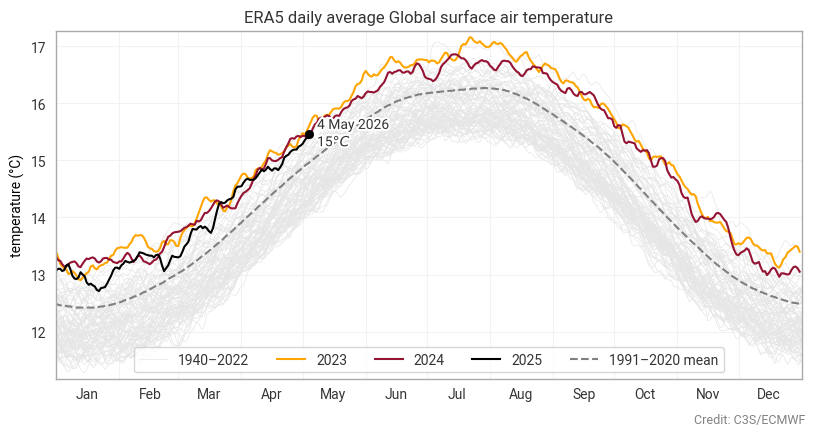

In [4]:
import matplotlib.patheffects as pe

chart = ekp.Climatology()

# Historical background (1940-2023 inclusive)
chart.line(
    da.sel(time=slice("1940", "2023")),
    linewidth=0.5, color="#e6e6e6", label="1940–2022",
)

# Recent years to highlight
chart.line(da.sel(time=slice("2024", "2024")), color="orange", label="2023")
chart.line(da.sel(time=slice("2025", "2025")), color=C3S_RED, label="2024")
chart.line(da.sel(time=slice("2026", "2026")), color="black", label="2025")

# Latest data point with label
chart.scatter(da.isel(time=-1), color="black", zorder=10)
chart.annotate(
    "{time:%-d %B %Y}\n{value}{units}", da.isel(time=-1),
    path_effects=[pe.withStroke(linewidth=3, foreground="white")],
    verticalalignment="center", xytext=(6, 0), textcoords="offset points",
)

# Climatological mean
chart.line(clim_daily, color="grey", linestyle="--", label="1991–2020 mean")

# Axis formatting
chart.xticks(frequency="M", period=True)
chart.ylabel("temperature (°C)")

chart.legend(ncols=5)
chart.title("ERA5 daily average Global surface air temperature")
chart.attribution("Credit: C3S/ECMWF", location="lower right")

chart.show()

### Key takeaways

- **`ekp.Climatology()`** creates a chart with a shared Jan–Dec x-axis, automatically remapping multi-year timeseries data so that years can be compared side by side.
- **Layered plotting** — call `.line()`, `.scatter()`, and `.annotate()` repeatedly on the same chart object to build up a multi-layer figure incrementally.
- **Metadata-aware annotations** — format strings like `"{time:%-d %B %Y}\n{value}{units}"` pull values directly from the data, so labels stay correct without any manual string replacing.
- **`clim_daily`** was computed by grouping on `day-of-year` and averaging, giving a single climatological cycle that earthkit-plots can overlay on the same Jan–Dec axis.
- **Standard matplotlib kwargs** (`linewidth`, `color`, `linestyle`, `zorder`) work as normal, so fine-grained styling requires no extra learning.